# Keras Regression Code Along Project
King County House Sales — predict house price using a neural network.

## Imports

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [9]:
import os
os.listdir()

['.config', 'kc_house_data.csv', '.ipynb_checkpoints', 'sample_data']

## Load Data

In [10]:
df = pd.read_csv('kc_house_data.csv')
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


## Exploratory Data Analysis

In [11]:
df.isnull().sum()

,0
id,0
date,0
price,0
bedrooms,0
bathrooms,0
sqft_living,0
sqft_lot,0
floors,0
waterfront,0
view,0


In [12]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,21613.0,4.580302e+09,2.876566e+09,1.000102e+06,2.123049e+09,3.904930e+09,7.308900e+09,9.900000e+09
price,21613.0,5.400881e+05,3.671272e+05,7.500000e+04,3.219500e+05,4.500000e+05,6.450000e+05,7.700000e+06
bedrooms,21613.0,3.370842e+00,9.300618e-01,0.000000e+00,3.000000e+00,3.000000e+00,4.000000e+00,3.300000e+01
bathrooms,21613.0,2.114757e+00,7.701632e-01,0.000000e+00,1.750000e+00,2.250000e+00,2.500000e+00,8.000000e+00
sqft_living,21613.0,2.079900e+03,9.184409e+02,2.900000e+02,1.427000e+03,1.910000e+03,2.550000e+03,1.354000e+04
sqft_lot,21613.0,1.510697e+04,4.142051e+04,5.200000e+02,5.040000e+03,7.618000e+03,1.068800e+04,1.651359e+06
floors,21613.0,1.494309e+00,5.399889e-01,1.000000e+00,1.000000e+00,1.500000e+00,2.000000e+00,3.500000e+00
waterfront,21613.0,7.541757e-03,8.651720e-02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
view,21613.0,2.343034e-01,7.663176e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.000000e+00
condition,21613.0,3.409430e+00,6.507430e-01,1.000000e+00,3.000000e+00,3.000000e+00,4.000000e+00,5.000000e+00


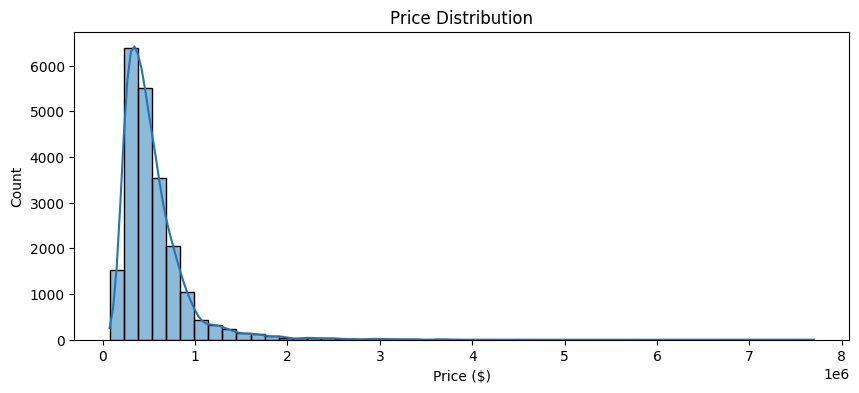

In [13]:
# Distribution of target variable
plt.figure(figsize=(10,4))
sns.histplot(df['price'], bins=50, kde=True)
plt.title('Price Distribution')
plt.xlabel('Price ($)')
plt.show()

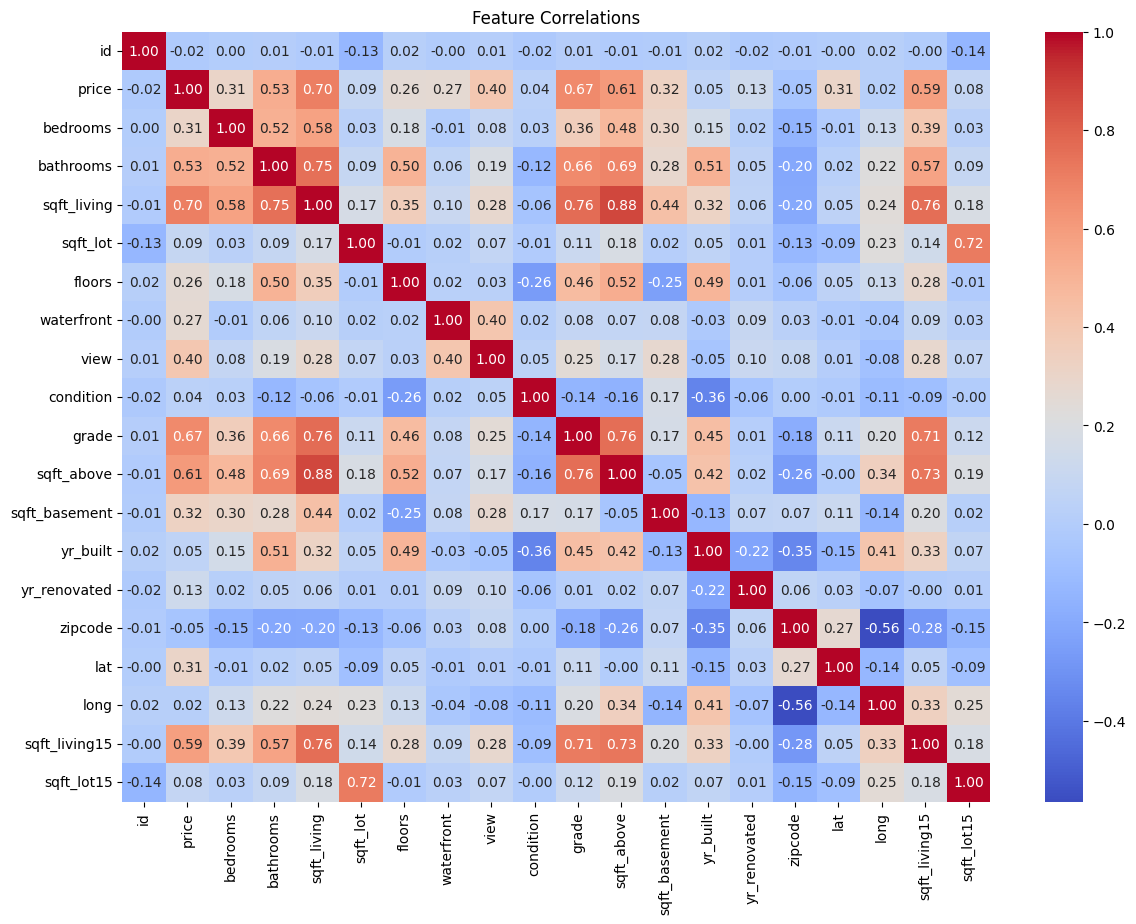

In [14]:
# Correlation heatmap
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlations')
plt.show()

In [15]:
# Top correlations with price
df.corr(numeric_only=True)['price'].sort_values(ascending=False)

,price
price,1.000000
sqft_living,0.702035
grade,0.667434
sqft_above,0.605567
sqft_living15,0.585379
bathrooms,0.525138
view,0.397293
sqft_basement,0.323816
bedrooms,0.308350
lat,0.307003


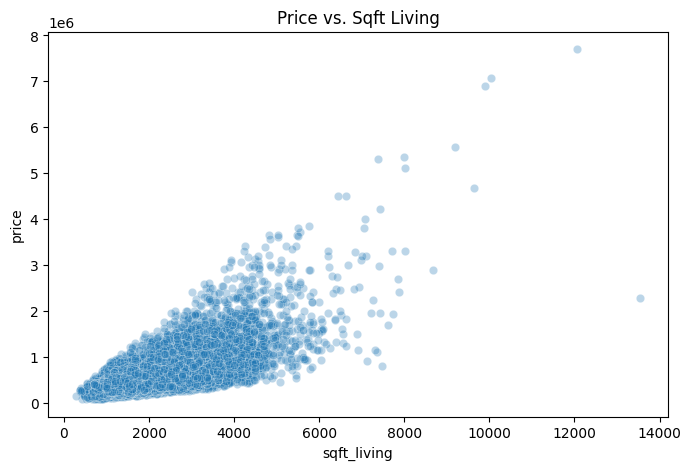

In [16]:
# Price vs sqft_living
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='sqft_living', y='price', alpha=0.3)
plt.title('Price vs. Sqft Living')
plt.show()

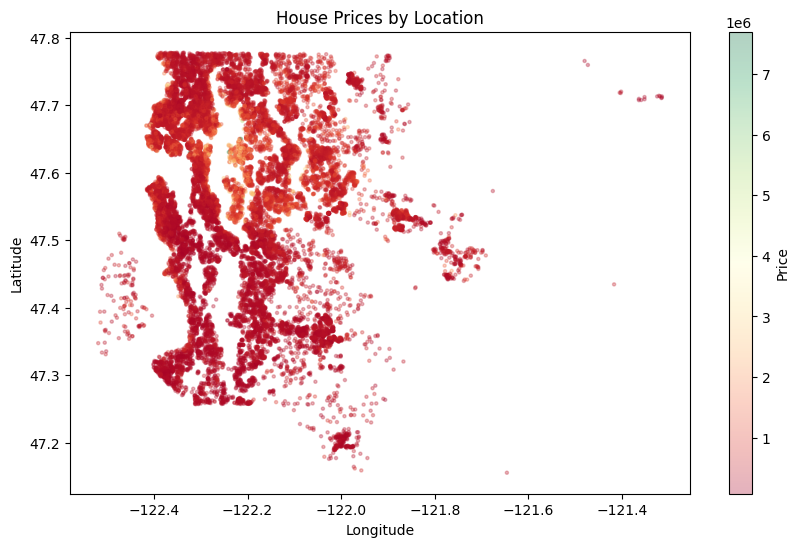

In [17]:
# Price vs geographic location
plt.figure(figsize=(10,6))
plt.scatter(df['long'], df['lat'], c=df['price'], cmap='RdYlGn',
            alpha=0.3, s=5)
plt.colorbar(label='Price')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('House Prices by Location')
plt.show()

## Feature Engineering

In [18]:
# Drop id (unique identifier, no predictive value)
# Drop date (raw string — would need extra parsing; excluded for simplicity)
df = df.drop(['id', 'date'], axis=1)
print('Remaining columns:', df.columns.tolist())

Remaining columns: ['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15']


## Train / Test Split

In [19]:
from sklearn.model_selection import train_test_split

X = df.drop('price', axis=1).values
y = df['price'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=101
)
print('Train size:', X_train.shape)
print('Test  size:', X_test.shape)

Train size: (15129, 18)
Test  size: (6484, 18)


## Scaling

In [20]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

## Build Keras Model

In [21]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

model = Sequential([
    Dense(19, activation='relu'),
    Dense(19, activation='relu'),
    Dense(19, activation='relu'),
    Dense(19, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Train Model

In [22]:
early_stop = EarlyStopping(monitor='val_loss', mode='min',
                           verbose=1, patience=25)

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    batch_size=128,
    epochs=400,
    callbacks=[early_stop]
)

Epoch 1/400
119/119 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 416281853952.0000 - val_loss: 432945233920.0000
Epoch 2/400
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 428666191872.0000 - val_loss: 427732107264.0000
Epoch 3/400
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 414088593408.0000 - val_loss: 384585236480.0000
Epoch 4/400
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 349423665152.0000 - val_loss: 248025743360.0000
Epoch 5/400
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 189353574400.0000 - val_loss: 116773085184.0000
Epoch 6/400
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 98038259712.0000 - val_loss: 102191489024.0000
Epoch 7/400
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 90607624192.0000 - val_loss: 100591861760.0000
Epoch 8/400
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 93032546304.0000 - val_loss: 98838167552.0000
Epoch 9/400
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 95868354560.0000 - val_loss: 96902176768.0000
Epoch 10/400
119/119 ━━━━

## Training Curves

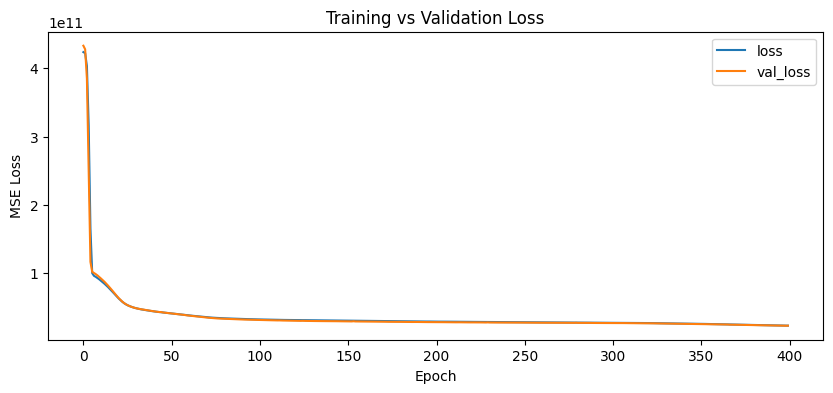

In [23]:
losses = pd.DataFrame(history.history)
losses.plot(figsize=(10,4))
plt.title('Training vs Validation Loss')
plt.ylabel('MSE Loss')
plt.xlabel('Epoch')
plt.show()

## Evaluate

In [24]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

predictions = model.predict(X_test)

mae  = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print(f'MAE  : ${mae:,.2f}')
print(f'RMSE : ${rmse:,.2f}')
print(f'Mean house price: ${y_test.mean():,.2f}')

203/203 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
MAE  : $94,479.11
RMSE : $153,135.64
Mean house price: $541,116.98


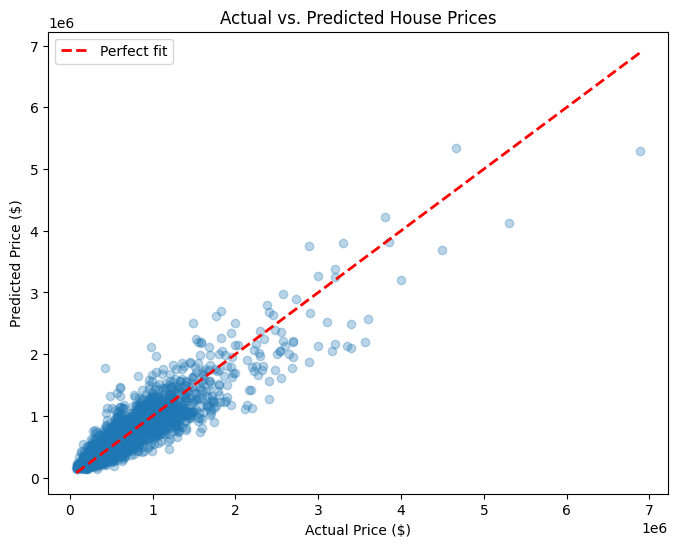

In [25]:
# Actual vs Predicted scatter
plt.figure(figsize=(8,6))
plt.scatter(y_test, predictions, alpha=0.3)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect fit')
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.title('Actual vs. Predicted House Prices')
plt.legend()
plt.show()

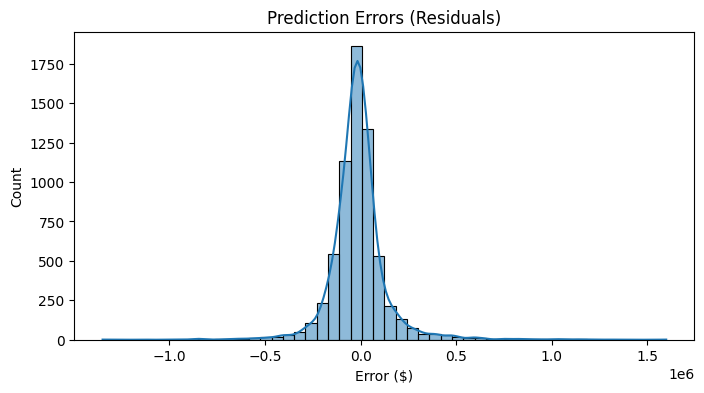

In [26]:
# Residuals
errors = y_test - predictions.flatten()
plt.figure(figsize=(8,4))
sns.histplot(errors, bins=50, kde=True)
plt.title('Prediction Errors (Residuals)')
plt.xlabel('Error ($)')
plt.show()

## Save Weights

In [27]:
import pickle

# Save scaler
with open('scaler_weights.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Save model weights
with open('model_weights.pkl', 'wb') as f:
    pickle.dump(model.get_weights(), f)

print('✓ scaler_weights.pkl saved')
print('✓ model_weights.pkl saved')

✓ scaler_weights.pkl saved
✓ model_weights.pkl saved
